In [1]:
import scipy as sp
from scipy.special import jv, hankel2, yv, spherical_jn, spherical_yn
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, argmin, log, unravel_index, pi, array
from utils import e_r_cpa_numerator, e_r_cpa, hl2, hl2prime, hl1, hl1prime, e_r_recursive_cpa
from refractiveindex import RefractiveIndexMaterial

# We try to re-create Figure 7 of the paper

In [2]:
omega_p = 7.9 # Bulk plasma frequency of Gold in eV
hbar_c = 6.58211957 * 3 * 10 #200 # in nanometers * eV

In [3]:
def gold_drude(omega_over_omega_p, omega_p=7.9, gamma_e=0.09):
    return 1-1/(omega_over_omega_p*(omega_over_omega_p+1j*gamma_e/omega_p))

In [6]:
K = 100
N = 200
l = 1
R = 6
Hs = linspace(0.1, 0.8, K)
omega_over_omega_ps_real = linspace(0.01, 0.4, N) # range of real(omega)/omega_p
omega_over_omega_ps_imag = linspace(0.0001, 0.4, N) # range of imag(omega)/omega_p
omega_over_omega_ps = omega_over_omega_ps_real.reshape((N, 1)).repeat(N, axis=1) - 1j*omega_over_omega_ps_imag.reshape((1, N)).repeat(N, axis=0)
gamma_e = 0.09 # Some electron scattering 
gammas_no_surface_scattering = np.zeros((K, N))
heatmap_data_no_surface_scattering = np.zeros((K, N))
for (H_idx, H) in enumerate(Hs):
    if (H_idx % 10) == 0:
        print(H_idx)
    epsilon2 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); epsilon1 =  ones((N, N))
    kR = R * omega_over_omega_ps
    previous_coefficients = np.array([1, 1])
    
    next_coefficients = e_r_recursive_cpa(previous_coefficients, l, epsilon1, epsilon2, kR)
    
    epsilon2 = ones((N, N)) ; epsilon1 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); 
    kR =  (H+R) * omega_over_omega_ps
    next_coefficients = e_r_recursive_cpa(next_coefficients, l, epsilon1, epsilon2, kR)
    
    scattering_amplitudes = np.abs(next_coefficients[0, ...]/next_coefficients[1, ...])**2
    heatmap_data_no_surface_scattering[H_idx, :] =  scattering_amplitudes.max(axis=1) # maximum across all imaginary values for the frequency
    gammas_no_surface_scattering[H_idx, :] = omega_over_omega_ps_imag[scattering_amplitudes.argmax(axis=1)]


0
10
20
30
40
50
60
70
80
90


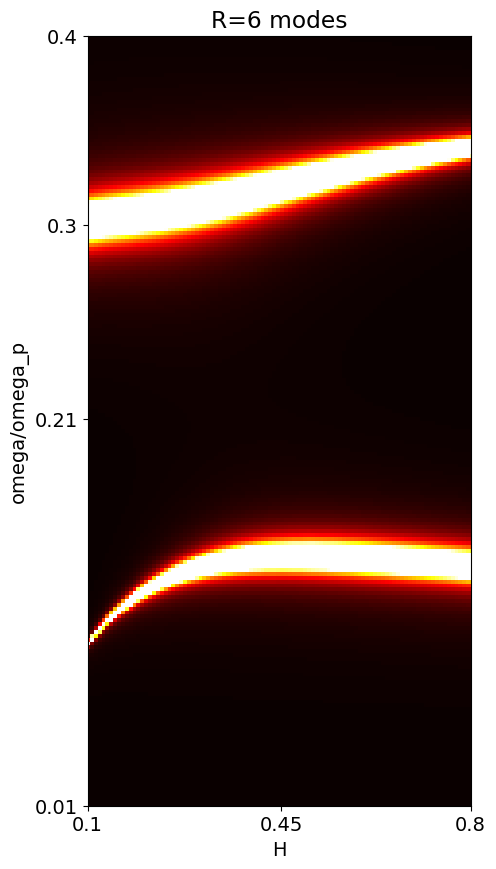

In [7]:
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(15,10))
ax.imshow(heatmap_data_no_surface_scattering.T, cmap="hot", vmin=1, vmax=100, origin="lower");
ax.set_xticks([0, K/2, K-1], Hs[[0, round(K/2), K-1]].round(2))
ax.set_yticks([0, N/2, N*3/4, N-1], omega_over_omega_ps_real[[0, round(N/2), round(3*N/4), N-1]].round(2))
ax.set_xlim(0, K-1)
ax.set_ylim(0, N-1);
ax.set_xlabel("H")
ax.set_ylabel("omega/omega_p");
ax.set_title(f"R={R} modes");

In [8]:
x, y = np.where(heatmap_data_no_surface_scattering > 120) # Find where the modes are 
sphere_mode_idxs = np.where(omega_over_omega_ps_real[y] < 0.2) # Indices for the lowest mode
x = x[sphere_mode_idxs]
y = y[sphere_mode_idxs]
sphere_mode_filter_idxs = np.array([np.where(x==i)[0][0] for i in range(0, 100)])
x_sphere_mode = x[sphere_mode_filter_idxs]
y_sphere_mode = y[sphere_mode_filter_idxs]

x, y = np.where(heatmap_data_no_surface_scattering > 1000) # Find where the modes are 
void_mode_idxs = np.where(omega_over_omega_ps_real[y] > 0.2) # Indices for the lowest mode
x = x[void_mode_idxs]
y = y[void_mode_idxs]
void_mode_filter_idxs = np.array([np.where(x==i)[0][0] for i in range(0, 100)])
x_void_mode = x[void_mode_filter_idxs]
y_void_mode = y[void_mode_filter_idxs]

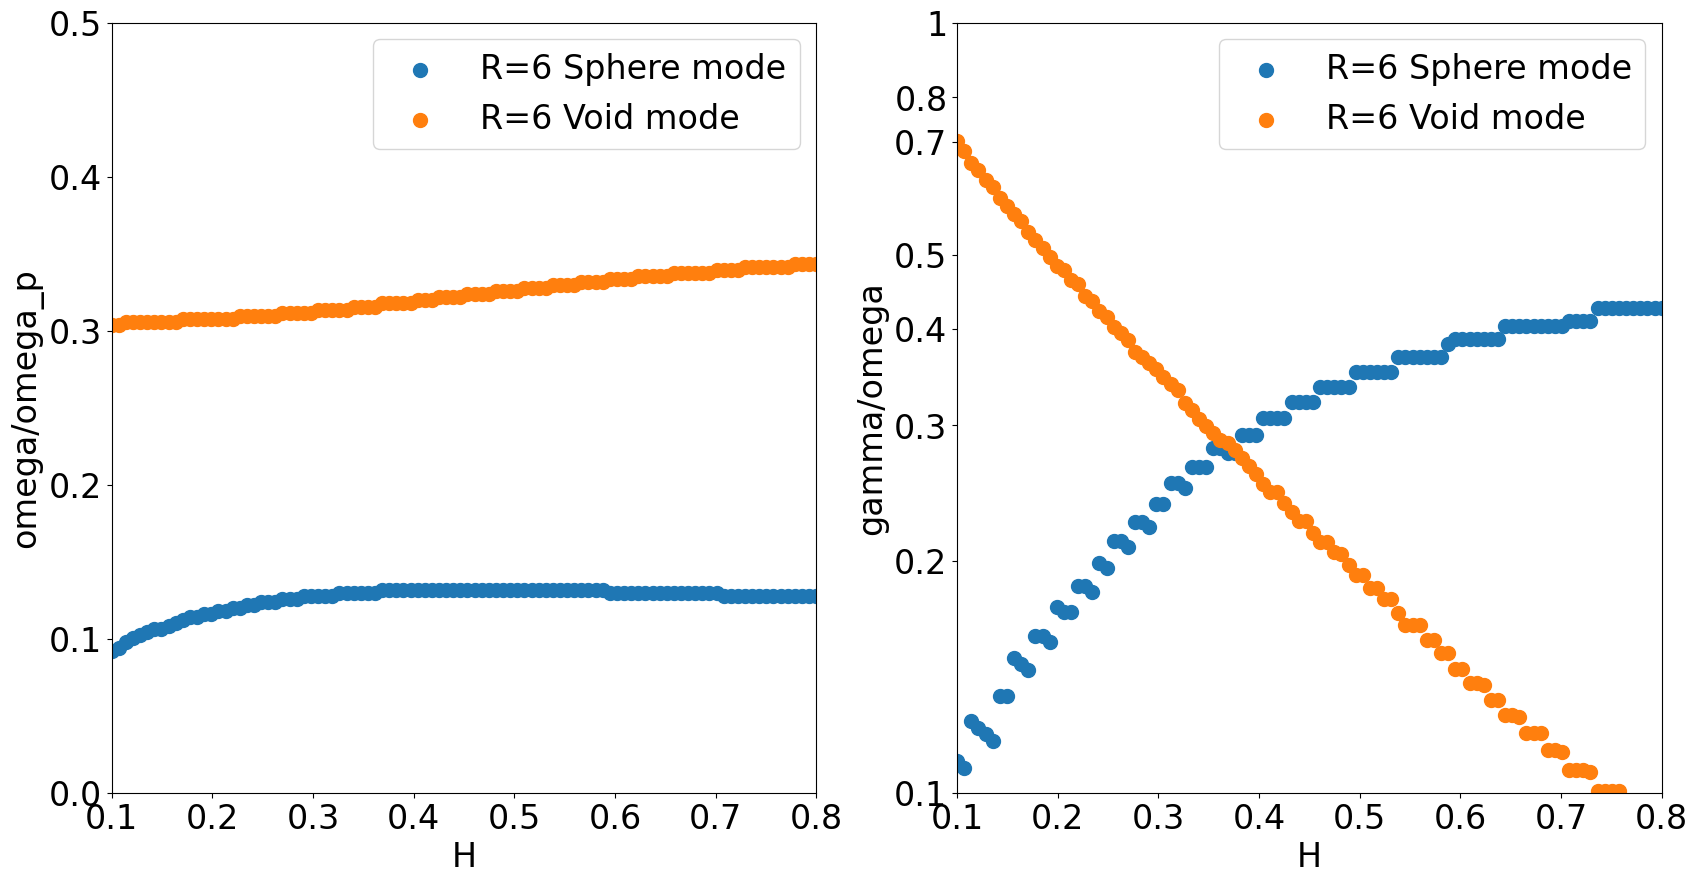

In [9]:
colors = ["aquamarine", "turquoise", "lime"]
plt.rcParams.update({'font.size': 24})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.scatter(Hs[x_sphere_mode], omega_over_omega_ps_real[y_sphere_mode], s=100, label=f"R={R} Sphere mode");
ax1.scatter(Hs[x_void_mode], omega_over_omega_ps_real[y_void_mode], s=100, label=f"R={R} Void mode");

ax1.set_xlabel("H")
ax1.set_ylabel("omega/omega_p");
ax1.set_xlim(0.1, 0.8);
ax1.legend();
ax1.set_ylim(0, 0.5);

ax2.scatter(Hs[x_sphere_mode], log(gammas_no_surface_scattering[x_sphere_mode, y_sphere_mode]/omega_over_omega_ps_real[y_sphere_mode]), s=100, label=f"R={R} Sphere mode");
ax2.scatter(Hs[x_void_mode], log(gammas_no_surface_scattering[x_void_mode, y_void_mode]/omega_over_omega_ps_real[y_void_mode]), s=100, label=f"R={R} Void mode");
ax2.set_xlabel("H")
ax2.set_yticks([log(0.1), log(0.2), log(0.3), log(0.4), log(0.5), log(0.7), log(0.8), log(1)], [0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 0.8, 1])
ax2.set_ylabel("gamma/omega");
ax2.set_xlim(0.1, 0.8);
ax2.legend();
ax2.set_ylim(log(0.1), log(1));

In [11]:
K = 100
N = 50
optimized_gammas_sphere_void = []
optimized_omegas_sphere_void = []
optimized_Hs_sphere_void = []
for (x, y) in zip([x_sphere_mode, x_void_mode], [y_sphere_mode, y_void_mode]):
    optimized_gammas = np.zeros(Hs[x].shape[0])
    optimized_omegas = np.zeros(Hs[x].shape[0])
    optimized_Hs = np.zeros(Hs[x].shape[0])

    for idx in range(0, Hs[x].shape[0]):
        if (idx % 10) == 0: 
            print(idx)
        H = Hs[x[idx]]
        starting_omega = omega_over_omega_ps_real[y[idx]]
        starting_gamma = gammas_no_surface_scattering[x[idx], y[idx]]
    
        omega_over_omega_ps_real_zoom = linspace(0.8, 1.2, N) * starting_omega 
        omega_over_omega_ps_imag_zoom = linspace(0.8, 1.2, N) * starting_gamma
        omega_over_omega_ps = omega_over_omega_ps_real_zoom.reshape((N, 1)).repeat(N, axis=1) - 1j*omega_over_omega_ps_imag_zoom.reshape((1, N)).repeat(N, axis=0)
    
        epsilon2 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); epsilon1 =  ones((N, N))
        kR = R * omega_over_omega_ps
        previous_coefficients = np.array([1, 1])
        
        next_coefficients = e_r_recursive_cpa(previous_coefficients, l, epsilon1, epsilon2, kR)
        
        epsilon2 = ones((N, N)) ; epsilon1 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); 
        kR =  (H+R) * omega_over_omega_ps
        next_coefficients = e_r_recursive_cpa(next_coefficients, l, epsilon1, epsilon2, kR)
        
        scattering_amplitudes = np.abs(next_coefficients[0, ...]/next_coefficients[1, ...])**2
        max_idx = scattering_amplitudes.argmax()
        row, col = unravel_index(max_idx, (N, N))
        optimized_Hs[idx] = H
        optimized_omegas[idx] = omega_over_omega_ps_real_zoom[row]
        optimized_gammas[idx] = omega_over_omega_ps_imag_zoom[col]

    optimized_gammas_sphere_void.append(optimized_gammas)
    optimized_omegas_sphere_void.append(optimized_omegas)
    optimized_Hs_sphere_void.append(optimized_Hs)


0
10
20
30
40
50
60
70
80
90
0
10
20
30
40
50
60
70
80
90


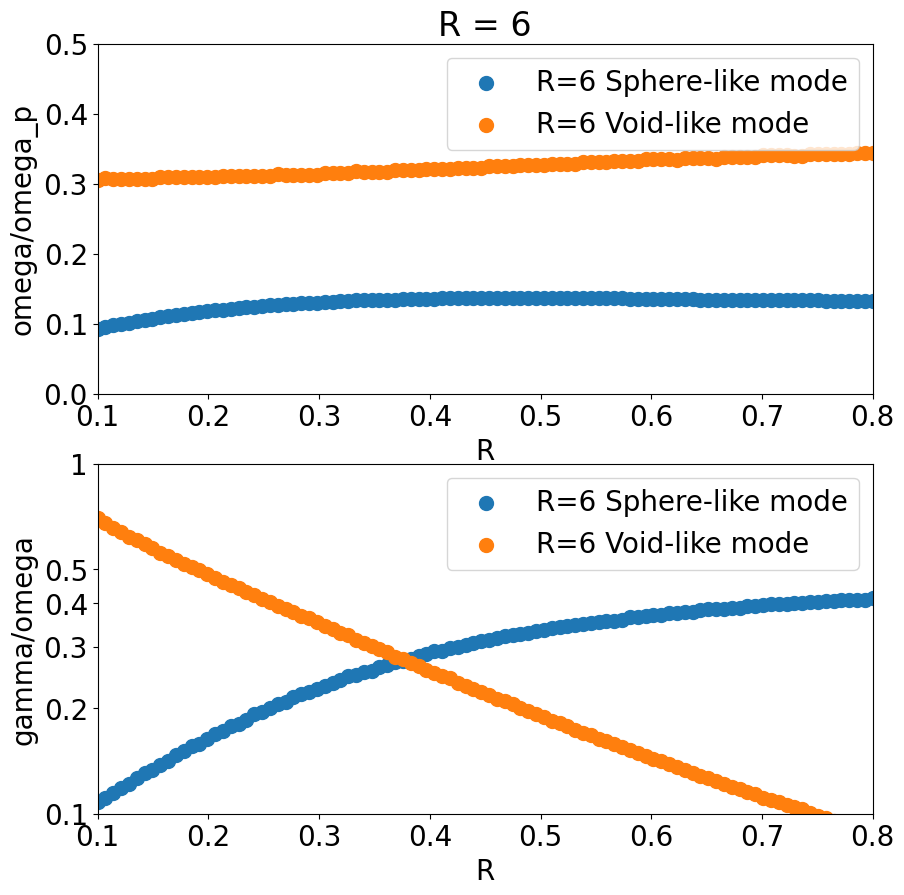

In [12]:
no_surface_scattering_inv_Q_sphere = optimized_gammas_sphere_void[0]/optimized_omegas_sphere_void[0]
no_surface_scattering_inv_Q_void = optimized_gammas_sphere_void[1]/optimized_omegas_sphere_void[1]

plt.rcParams.update({'font.size': 20})
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
ax1.scatter(optimized_Hs_sphere_void[0], optimized_omegas_sphere_void[0], s=100, label=f"R={R} Sphere-like mode")
ax1.scatter(optimized_Hs_sphere_void[1], optimized_omegas_sphere_void[1], s=100, label=f"R={R} Void-like mode")

ax2.scatter(optimized_Hs_sphere_void[0], log(no_surface_scattering_inv_Q_sphere), s=100, label=f"R={R} Sphere-like mode")
ax2.scatter(optimized_Hs_sphere_void[1], log(no_surface_scattering_inv_Q_void), s=100, label=f"R={R} Void-like mode")

ax1.set_xlabel("R")
ax1.set_ylabel("omega/omega_p");
ax1.set_xlim(0.1, 0.8);
ax1.set_ylim(0, 0.5);
ax1.legend();
ax2.set_yticks([log(0.1), log(0.2), log(0.3), log(0.4), log(0.5), log(1)], [0.1, 0.2, 0.3, 0.4, 0.5, 1])
ax2.set_ylabel("gamma/omega");
ax2.set_xlabel("R")
ax2.set_xlim(0.1, 0.8);
ax2.set_ylim(log(0.1), log(1));
ax2.legend();
ax1.set_title("R = 6");

# Now we introduce surface scattering 

In [13]:
def gamma_surface(R, H, v_F_over_c = (1.4/3)/100):
    s = R/(R+H)
    prefactor = omega_p*v_F_over_c/(R+H)
    L = 1/(1+s**2)-s/2-(1/4)*(1-s**2)/(1+s**2)*(1-s)*log((1-s)/(1+s))
    return prefactor/L

In [15]:
K = 100
N = 200
l = 1
Hs = linspace(0.05, 0.8, K)
R = 6
omega_over_omega_ps_real = linspace(0.01, 0.4, N) # range of real(omega)/omega_p
omega_over_omega_ps_imag = linspace(0.0001, 0.4, N) # range of imag(omega)/omega_p
omega_over_omega_ps = omega_over_omega_ps_real.reshape((N, 1)).repeat(N, axis=1) - 1j*omega_over_omega_ps_imag.reshape((1, N)).repeat(N, axis=0)
gammas_with_surface_scattering = np.zeros((K, N))
heatmap_data_with_surface_scattering = np.zeros((K, N))
for (H_idx, H) in enumerate(Hs):
    gamma_e = 0.09 + gamma_surface(R, H) # Includes surface scattering

    if (H_idx % 10) == 0:
        print(H_idx)
        print(gamma_e)
    epsilon2 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); epsilon1 =  ones((N, N))
    kR = R * omega_over_omega_ps
    previous_coefficients = np.array([1, 1])
    
    next_coefficients = e_r_recursive_cpa(previous_coefficients, l, epsilon1, epsilon2, kR)
    
    epsilon2 = ones((N, N)) ; epsilon1 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); 
    kR =  (H+R) * omega_over_omega_ps
    next_coefficients = e_r_recursive_cpa(next_coefficients, l, epsilon1, epsilon2, kR)
    
    scattering_amplitudes = np.abs(next_coefficients[0, ...]/next_coefficients[1, ...])**2
    heatmap_data_with_surface_scattering[H_idx, :] =  scattering_amplitudes.max(axis=1) # maximum across all imaginary values for the frequency
    gammas_with_surface_scattering[H_idx, :] = omega_over_omega_ps_imag[scattering_amplitudes.argmax(axis=1)]


0
0.8175513362162371
10
0.374944501999098
20
0.26557406547327156
30
0.21617211891591157
40
0.18808986114623608
50
0.17000688018620558
60
0.157407658948643
70
0.14813747350177303
80
0.14103839354865297
90
0.13543287999934683


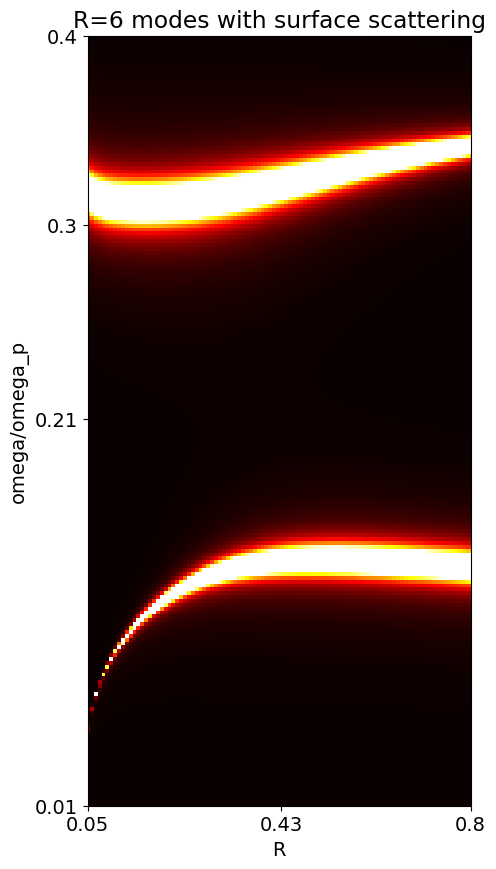

In [16]:
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(15,10))
ax.imshow(heatmap_data_with_surface_scattering.T, cmap="hot", vmin=1, vmax=100, origin="lower");
ax.set_xticks([0, K/2, K-1], Hs[[0, round(K/2), K-1]].round(2))
ax.set_yticks([0, N/2, N*3/4, N-1], omega_over_omega_ps_real[[0, round(N/2), round(3*N/4), N-1]].round(2))
ax.set_xlim(0, K-1)
ax.set_ylim(0, N-1);
ax.set_xlabel("R")
ax.set_ylabel("omega/omega_p");
ax.set_title(f"R={R} modes with surface scattering");

In [17]:
x, y = np.where(heatmap_data_with_surface_scattering > 10) # Find where the modes are 
sphere_mode_idxs = np.where(omega_over_omega_ps_real[y] < 0.2) # Indices for the lowest mode
void_mode_idxs = np.where(omega_over_omega_ps_real[y] > 0.2) # Indices for the lowest mode
x = x[sphere_mode_idxs]
y = y[sphere_mode_idxs]
sphere_mode_filter_idxs = np.array([np.where(x==i)[0][0] for i in range(0, 100)])
x_sphere_mode = x[sphere_mode_filter_idxs]
y_sphere_mode = y[sphere_mode_filter_idxs]

x, y = np.where(heatmap_data_with_surface_scattering > 10) # Find where the modes are 
x = x[void_mode_idxs]
y = y[void_mode_idxs]
void_mode_filter_idxs = np.array([np.where(x==i)[0][0] for i in range(0, 100)])
x_void_mode = x[void_mode_filter_idxs]
y_void_mode = y[void_mode_filter_idxs]

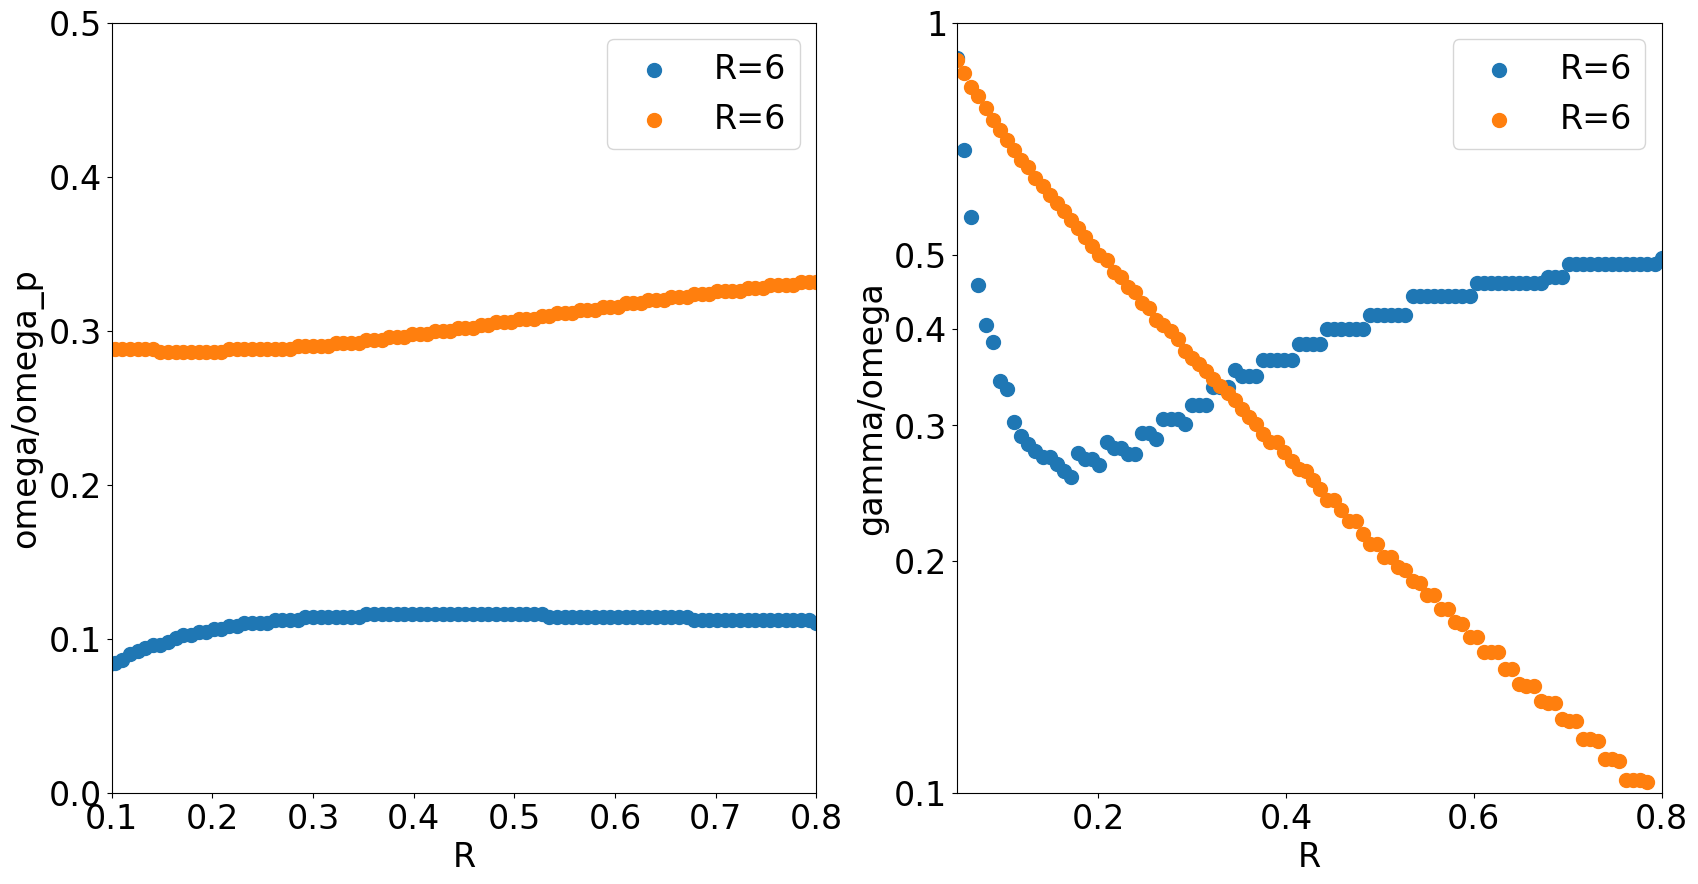

In [18]:
colors = ["aquamarine", "turquoise", "lime"]
plt.rcParams.update({'font.size': 24})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.scatter(Hs[x_sphere_mode], omega_over_omega_ps_real[y_sphere_mode], s=100, label=f"R={R}");
ax1.scatter(Hs[x_void_mode], omega_over_omega_ps_real[y_void_mode], s=100, label=f"R={R}");

ax1.set_xlabel("R")
ax1.set_ylabel("omega/omega_p");
ax1.set_xlim(0.1, 0.8);
ax1.legend();
ax1.set_ylim(0, 0.5);

ax2.scatter(Hs[x_sphere_mode], log(gammas_with_surface_scattering[x_sphere_mode, y_sphere_mode]/omega_over_omega_ps_real[y_sphere_mode]), s=100, label=f"R={R}");
ax2.scatter(Hs[x_void_mode], log(gammas_with_surface_scattering[x_void_mode, y_void_mode]/omega_over_omega_ps_real[y_void_mode]), s=100, label=f"R={R}");

ax2.set_xlabel("R")
ax2.set_yticks([log(0.1), log(0.2), log(0.3), log(0.4), log(0.5), log(1)], [0.1, 0.2, 0.3, 0.4, 0.5, 1])
ax2.set_ylabel("gamma/omega");
ax2.set_xlim(0.05, 0.8);
ax2.legend();
ax2.set_ylim(log(0.1), log(1));


In [20]:
K = 100
N = 200
optimized_gammas_sphere_void_surface = []
optimized_omegas_sphere_void_surface = []
optimized_Hs_sphere_void_surface = []

for (x, y) in zip([x_sphere_mode, x_void_mode], [y_sphere_mode, y_void_mode]):
    optimized_gammas = np.zeros(Hs[x].shape[0])
    optimized_omegas = np.zeros(Hs[x].shape[0])
    optimized_Hs = np.zeros(Hs[x].shape[0])

    for idx in range(0, Hs[x].shape[0]):
        if (idx % 10) == 0: 
            print(idx)
        H = Hs[x[idx]]
        gamma_e = 0.09 + gamma_surface(R, H) # Includes surface scattering
    
        starting_omega = omega_over_omega_ps_real[y[idx]]
        starting_gamma = gammas_with_surface_scattering[x[idx], y[idx]]
    
        omega_over_omega_ps_real_zoom = linspace(0.8, 1.2, N) * starting_omega 
        omega_over_omega_ps_imag_zoom = linspace(0.8, 1.2, N) * starting_gamma
        omega_over_omega_ps = omega_over_omega_ps_real_zoom.reshape((N, 1)).repeat(N, axis=1) - 1j*omega_over_omega_ps_imag_zoom.reshape((1, N)).repeat(N, axis=0)
    
        epsilon2 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); epsilon1 =  ones((N, N))
        kR = R * omega_over_omega_ps
        previous_coefficients = np.array([1, 1])
        
        next_coefficients = e_r_recursive_cpa(previous_coefficients, l, epsilon1, epsilon2, kR)
        
        epsilon2 = ones((N, N)) ; epsilon1 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); 
        kR =  (H+R) * omega_over_omega_ps
        next_coefficients = e_r_recursive_cpa(next_coefficients, l, epsilon1, epsilon2, kR)
        
        scattering_amplitudes = np.abs(next_coefficients[0, ...]/next_coefficients[1, ...])**2
        max_idx = scattering_amplitudes.argmax()
        row, col = unravel_index(max_idx, (N, N))
        optimized_Hs[idx] = H
        optimized_omegas[idx] = omega_over_omega_ps_real_zoom[row]
        optimized_gammas[idx] = omega_over_omega_ps_imag_zoom[col]

    optimized_gammas_sphere_void_surface.append(optimized_gammas)
    optimized_omegas_sphere_void_surface.append(optimized_omegas)
    optimized_Hs_sphere_void_surface.append(optimized_Hs)


0
10
20
30
40
50
60
70
80
90
0
10
20
30
40
50
60
70
80
90


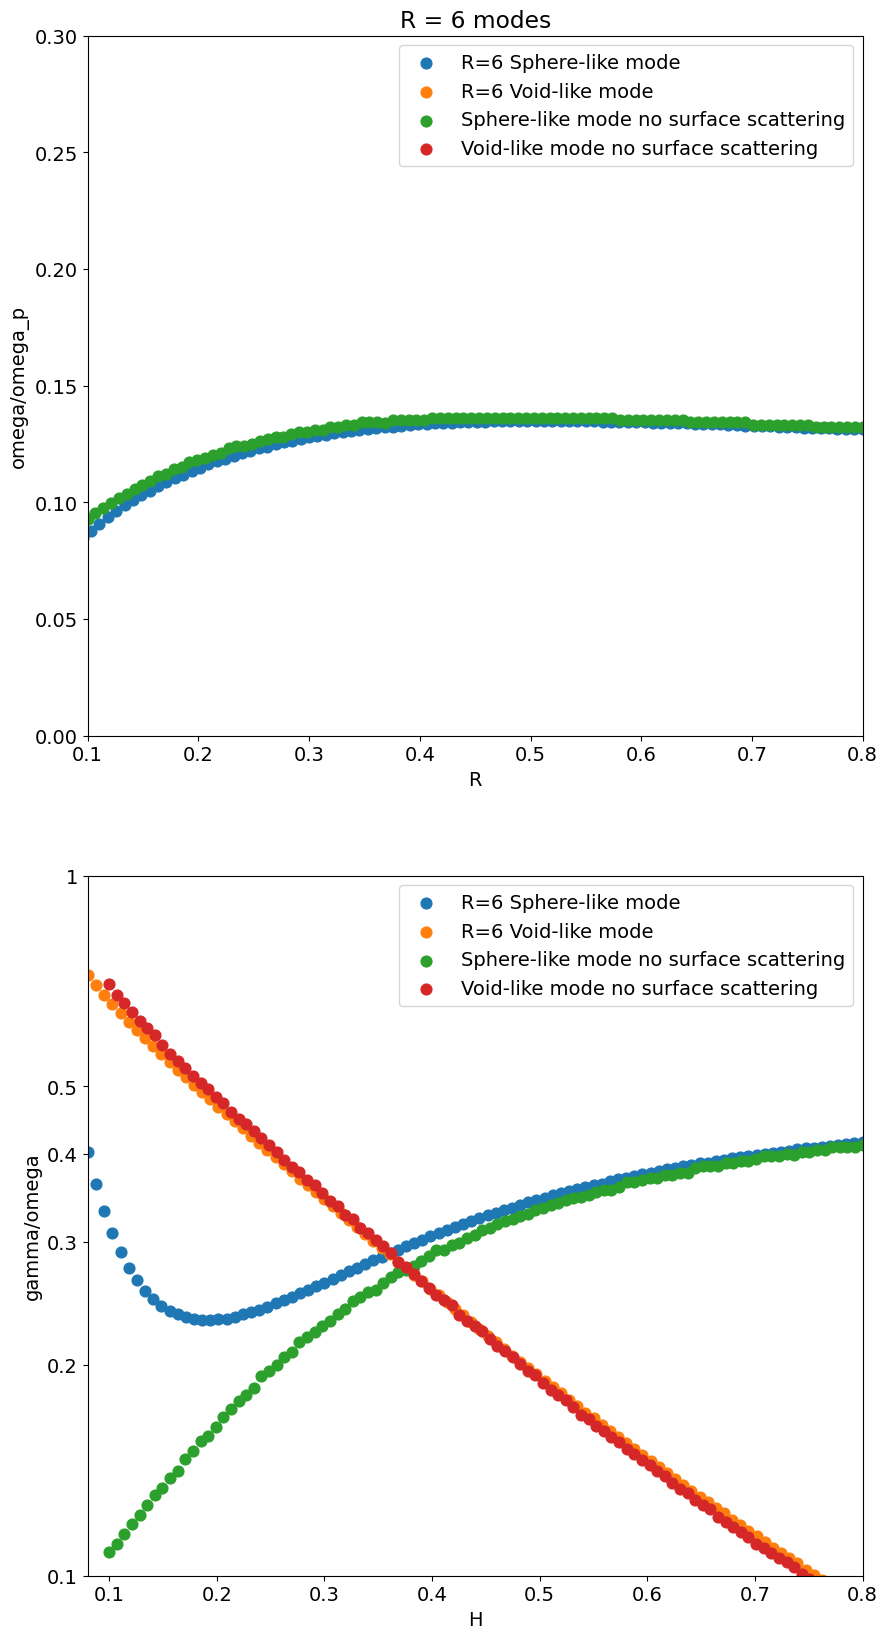

In [21]:
s = 60
with_surface_scattering_inv_Q_sphere = optimized_gammas_sphere_void_surface[0]/optimized_omegas_sphere_void_surface[0]
with_surface_scattering_inv_Q_void = optimized_gammas_sphere_void_surface[1]/optimized_omegas_sphere_void_surface[1]

plt.rcParams.update({'font.size': 14})
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 20))

ax1.scatter(optimized_Hs_sphere_void_surface[0], optimized_omegas_sphere_void_surface[0], s=s, label=f"R={R} Sphere-like mode")
ax1.scatter(optimized_Hs_sphere_void_surface[1], optimized_omegas_sphere_void_surface[1], s=s, label=f"R={R} Void-like mode")

ax1.scatter(optimized_Hs_sphere_void[0], optimized_omegas_sphere_void[0], s=s, label=f"Sphere-like mode no surface scattering")
ax1.scatter(optimized_Hs_sphere_void[1], optimized_omegas_sphere_void[1], s=s, label=f"Void-like mode no surface scattering")

ax2.scatter(optimized_Hs_sphere_void_surface[0], log(with_surface_scattering_inv_Q_sphere), s=s, label=f"R={R} Sphere-like mode")
ax2.scatter(optimized_Hs_sphere_void_surface[1], log(with_surface_scattering_inv_Q_void), s=s, label=f"R={R} Void-like mode")

ax2.scatter(optimized_Hs_sphere_void[0], log(no_surface_scattering_inv_Q_sphere), s=s, label=f"Sphere-like mode no surface scattering")
ax2.scatter(optimized_Hs_sphere_void[1], log(no_surface_scattering_inv_Q_void), s=s, label=f"Void-like mode no surface scattering")

ax1.set_xlabel("R")
ax1.set_ylabel("omega/omega_p");
ax1.set_xlim(0.1, 0.8);
ax1.set_ylim(0, 0.3);
ax1.legend();
ax2.set_yticks([log(0.1), log(0.2), log(0.3), log(0.4), log(0.5), log(1)], [0.1, 0.2, 0.3, 0.4, 0.5, 1])
ax2.set_ylabel("gamma/omega");
ax2.set_xlabel("H")
ax2.set_xlim(0.08, 0.8);
ax2.set_ylim(log(0.1), log(1));
ax2.legend();
ax1.set_title("R = 6 modes");
